In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Disable GPU

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy import signal

import numpy as np
import networkx as nx
from stellargraph import StellarGraph

from stellargraph.mapper import PaddedGraphGenerator
from stellargraph.layer import GCNSupervisedGraphClassification

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.metrics import roc_auc_score, classification_report, f1_score
from tensorflow.keras.metrics import Recall, Precision
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler, Callback
from sklearn.metrics import precision_recall_fscore_support, classification_report, roc_auc_score, roc_curve, f1_score, confusion_matrix

In [4]:
os.environ["CUDA_VISIBLE_DEVICES"]

'-1'

In [5]:
# run model
epochs = 250
#_v5 got 94 accuracy

# Define the checkpoint filepath
checkpoint_dir = '/home/qdj17/synthetic_data_analysis/gcnn/checkpoints'
model_title = "smmfall_yt12r_ttm_smv_128_all_v2"
model_name = 'gcnn_'+ model_title +'.h5'

#checkpoint_filepath = os.path.join(checkpoint_dir, 'checkpoint_{epoch:02d}-{val_loss:.2f}.h5')
checkpoint_filepath = os.path.join(checkpoint_dir, model_name)

In [6]:
path_numpies = '/home/qdj17/Datasets/output_numpies/smartfall_mm/'

# Load the data from .npz files
train = np.load(path_numpies+'training_smmfall_yt12r_ttm_smv_all_128.npz', allow_pickle=True)
val = np.load(path_numpies+'validation_smmfall_yt12r_ttm_smv_all_128.npz', allow_pickle=True)
test = np.load(path_numpies+'testing_smmfall_yt12r_ttm_smv_all_128.npz', allow_pickle=True)

In [7]:
x_train_seqs = train['data']
y_train_seqs = train['labels']
x_val_seqs = val['data']
y_val_seqs = val['labels']
x_test_seqs = test['data']
y_test_seqs = test['labels']

print("Shapes before function call:")
print(f"x_train_seqs shape: {x_train_seqs.shape}")
print(f"y_train_seqs shape: {y_train_seqs.shape}")
print(f"x_val_seqs shape: {x_val_seqs.shape}")
print(f"y_val_seqs shape: {y_val_seqs.shape}")
print(f"x_test_seqs shape: {x_test_seqs.shape}")
print(f"y_test_seqs shape: {y_test_seqs.shape}")

Shapes before function call:
x_train_seqs shape: (32888, 128, 4)
y_train_seqs shape: (32888, 1)
x_val_seqs shape: (769, 128, 4)
y_val_seqs shape: (769, 1)
x_test_seqs shape: (1192, 128, 4)
y_test_seqs shape: (1192, 1)


In [8]:
import numpy as np
import networkx as nx
from scipy.signal import find_peaks
from stellargraph import StellarGraph
import time

def compute_orientation(x, y, z):
    pitch = np.arctan2(y, np.sqrt(x**2 + z**2))
    roll = np.arctan2(-x, z)
    return pitch, roll

def add_basic_features(data, window_size=5):
    n_samples, n_nodes, n_features = data.shape
    basic_features = np.zeros((n_samples, n_nodes, 11))  # Correct size for essential features
    print("Starting feature extraction...")
    
    total_time = 0  # To track total time for feature extraction
    
    for i in range(n_samples):
        #if i % 100 == 0:
            #print(f"Processing sample {i}/{n_samples}")
        
        start_time = time.time()  # Start timing for each sample
        for j in range(n_nodes):
            x, y, z, magnitude = data[i, j, :]
            
            # Sliding window statistics
            start = max(0, j - window_size)
            end = min(n_nodes, j + window_size + 1)
            window = data[i, start:end, :]
            
            mean_vals = np.mean(window, axis=0)
            std_vals = np.std(window, axis=0)
            
            # Peaks
            peaks, _ = find_peaks(window[:, 3])  # Assuming magnitude is the 4th feature
            
            # Orientation
            pitch, roll = compute_orientation(x, y, z)
            
            basic_features[i, j, :4] = mean_vals
            basic_features[i, j, 4:8] = std_vals
            basic_features[i, j, 8] = len(peaks)
            basic_features[i, j, 9] = pitch
            basic_features[i, j, 10] = roll
        
        end_time = time.time()  # End timing for each sample
        total_time += (end_time - start_time)
    
    avg_time_per_sample = total_time / n_samples
    print(f"Average time per sample for feature extraction: {avg_time_per_sample:.4f} seconds")
    
    return np.concatenate((data, basic_features), axis=2)

def create_graphs_as_arrays(data, labels, window_size=5):
    data = add_basic_features(data, window_size)
    graphs = []
    graph_labels = []
    print("Starting graph creation...")
    
    total_time = 0  # To track total time for graph creation

    for i in range(data.shape[0]):
        #if i % 100 == 0:
            #print(f"Processing graph {i}/{data.shape[0]}")
        
        start_time = time.time()  # Start timing for each graph
        G = nx.Graph()  # Creates an undirected graph
        
        for j in range(data.shape[1]):
            features = data[i, j, :]
            G.add_node(j, feature=features)
        
        for j in range(data.shape[1] - 1):
            feature_1 = G.nodes[j]['feature']
            feature_2 = G.nodes[j + 1]['feature']
            weight = np.linalg.norm(feature_1[:4] - feature_2[:4])  # Euclidean distance as the weight
            G.add_edge(j, j + 1, weight=weight)
        
        for node in G.nodes():
            combined_features = G.nodes[node]['feature']
            G.nodes[node]['combined_features'] = combined_features
        
        graphs.append(G)
        graph_labels.append(labels[i])  # Corrected to index labels as a 1D array
        
        end_time = time.time()  # End timing for each graph
        total_time += (end_time - start_time)
    
    avg_time_per_graph = total_time / data.shape[0]
    print(f"Average time per graph: {avg_time_per_graph:.4f} seconds")
    
    return graphs, np.array(graph_labels)

In [9]:
# Assuming x_train_seqs, y_train_seqs, x_val_seqs, y_val_seqs, x_test_seqs are already defined
print("Creating training graphs...")
train_graphs, train_labels = create_graphs_as_arrays(x_train_seqs, y_train_seqs)
print("Creating validation graphs...")
val_graphs, val_labels = create_graphs_as_arrays(x_val_seqs, y_val_seqs)
print("Creating test graphs...")
test_graphs, test_labels = create_graphs_as_arrays(x_test_seqs, y_test_seqs)

# Converting graphs to StellarGraph format
print("Converting training graphs to StellarGraph format...")
stellar_train_graphs = [StellarGraph.from_networkx(g, node_features="combined_features", edge_weight_attr="weight") for g in train_graphs]
print("Converting validation graphs to StellarGraph format...")
stellar_val_graphs = [StellarGraph.from_networkx(g, node_features="combined_features", edge_weight_attr="weight") for g in val_graphs]
print("Converting test graphs to StellarGraph format...")
stellar_test_graphs = [StellarGraph.from_networkx(g, node_features="combined_features", edge_weight_attr="weight") for g in test_graphs]

# Example to check the combined feature in a graph
node_features = stellar_train_graphs[0].node_features()
print("Node features:\n", node_features)

# Convert StellarGraph back to NetworkX to check edge weights
nx_graph = stellar_train_graphs[0].to_networkx()
edges_with_weights = nx_graph.edges(data=True)
print("Edges with weights:\n", [(u, v, data['weight']) for u, v, data in edges_with_weights])

Creating training graphs...
Starting feature extraction...


Average time per sample for feature extraction: 0.0052 seconds
Starting graph creation...
Average time per graph: 0.0012 seconds
Creating validation graphs...
Starting feature extraction...
Average time per sample for feature extraction: 0.0055 seconds
Starting graph creation...
Average time per graph: 0.0011 seconds
Creating test graphs...
Starting feature extraction...
Average time per sample for feature extraction: 0.0054 seconds
Starting graph creation...
Average time per graph: 0.0011 seconds
Converting training graphs to StellarGraph format...
Converting validation graphs to StellarGraph format...
Converting test graphs to StellarGraph format...
Node features:
 [[-5.6303115  -4.84068    -0.3278167  ...  1.         -0.7092929
   1.6289542 ]
 [-5.4987063  -4.3334017  -0.863809   ...  1.         -0.66151094
   1.726616  ]
 [-5.3359947  -3.426522   -1.9142581  ...  1.         -0.5436739
   1.9152399 ]
 ...
 [-1.0600204  -4.4578285   8.422736   ...  2.         -0.48354033
   0.1251940

In [10]:
# Creating graph generators for StellarGraph
batch_size = 32

# Create individual PaddedGraphGenerator instances for each dataset
train_generator = PaddedGraphGenerator(graphs=stellar_train_graphs)
val_generator = PaddedGraphGenerator(graphs=stellar_val_graphs)
test_generator = PaddedGraphGenerator(graphs=stellar_test_graphs)

# Generate the data flows for each dataset
train_gen = train_generator.flow(stellar_train_graphs, train_labels, batch_size=batch_size)
val_gen = val_generator.flow(stellar_val_graphs, val_labels, batch_size=batch_size)
test_gen = test_generator.flow(stellar_test_graphs, test_labels, batch_size=batch_size)


In [11]:
# Clear previous sessions to free up memory
K.clear_session()

In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Ensure labels are flat arrays
train_labels = np.ravel(y_train_seqs)

# Calculate class weights for binary classification
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

Class weights: {0: 2.9443151298119963, 1: 0.6022781379335604}


In [22]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Precision, Recall
from stellargraph.layer import GCNSupervisedGraphClassification

def create_graph_classification_model(generator):
    gc_model = GCNSupervisedGraphClassification(
        layer_sizes=[32, 32, 64],
        activations=["relu", "relu", "relu"],
        generator=generator,
        dropout=0.25,
    )
    x_inp, x_out = gc_model.in_out_tensors()
    predictions = Dense(units=512, activation="relu")(x_out)
    predictions = Dense(units=1, activation="sigmoid")(predictions)  

    model = Model(inputs=x_inp, outputs=predictions)
    opt = Adam(learning_rate=0.0001)

    model.compile(optimizer=opt, loss=BinaryCrossentropy(), metrics=["accuracy", Precision(), Recall()])  

    model.summary()
    
    return model

# Assuming you have calculated class weights
#class_weight = {0: 1.0, 1: 1.5}  # Example weights, adjust based on your data

model = create_graph_classification_model(train_generator)


Model: "model_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_12 (InputLayer)           [(None, None, 15)]   0                                            
__________________________________________________________________________________________________
dropout_14 (Dropout)            (None, None, 15)     0           input_12[0][0]                   
__________________________________________________________________________________________________
input_14 (InputLayer)           [(None, None, None)] 0                                            
__________________________________________________________________________________________________
graph_convolution_12 (GraphConv (None, None, 32)     512         dropout_14[0][0]                 
                                                                 input_14[0][0]             

In [12]:
# Fit the model
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1)

# Define the EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    mode='min', 
    patience=50, 
    verbose=1 
)

training_start_time = time.time()
history = model.fit(
    train_gen,
    epochs=500,
    validation_data=val_gen,
    shuffle=True,
    verbose=1,
    callbacks=[model_checkpoint_callback, early_stopping],
    class_weight=class_weight_dict
)

training_end_time = time.time()
training_duration = training_end_time - training_start_time
print(f"Total training time: {training_duration:.2f} seconds.")

  ...
    to  
  ['...']
  ...
    to  
  ['...']
Train for 1028 steps, validate for 25 steps
Epoch 1/500
1025/1028 [============================>.] - ETA: 0s - loss: 0.3735 - accuracy: 0.8739 - precision: 0.9906 - recall: 0.8561
Epoch 00001: val_loss improved from inf to 0.71279, saving model to /home/qdj17/synthetic_data_analysis/gcnn/checkpoints/gcnn_smmfall_yt12r_ttm_smv_128_all_v2.h5
1028/1028 [==============================] - 11s 11ms/step - loss: 0.3724 - accuracy: 0.8742 - precision: 0.9906 - recall: 0.8566 - val_loss: 0.7128 - val_accuracy: 0.6424 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/500
1026/1028 [============================>.] - ETA: 0s - loss: 0.1720 - accuracy: 0.9125 - precision: 0.9942 - recall: 0.8998
Epoch 00002: val_loss improved from 0.71279 to 0.67170, saving model to /home/qdj17/synthetic_data_analysis/gcnn/checkpoints/gcnn_smmfall_yt12r_ttm_smv_128_all_v2.h5
1028/1028 [==============================] - 11s 11ms/step - loss: 0.1717 - accur

In [13]:
import pickle
# Save the history
with open(checkpoint_dir+'/'+model_title+'.pkl', 'wb') as file:
    pickle.dump(history.history, file)

In [23]:
# Load best weights
model.load_weights(checkpoint_filepath)

# Evaluate the model
# Note: Instead of using `next()`, we use the `test_gen` object directly in `predict` method
y_pred_prob1 = model.predict(test_gen, verbose=1)

# Extract true labels
y_test_seqs = np.concatenate([y for _, y in test_gen], axis=0)

# Compute ROC AUC Score
roc_auc = roc_auc_score(y_test_seqs, y_pred_prob1)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Evaluate with different thresholds
for i in range(5, 100, 5):
    threshold = i / 100
    print("Threshold", threshold)
    y_pred_binary = (y_pred_prob1 >= threshold).astype(int)
    print(classification_report(y_test_seqs, y_pred_binary))

    f1 = f1_score(y_test_seqs, y_pred_binary)
    print(f"Updated F1 Score: {f1:.4f}")


38/38 [==============================] - 0s 7ms/step
ROC AUC Score: 0.9883
Threshold 0.05
              precision    recall  f1-score   support

           0       0.99      0.80      0.89       792
           1       0.72      0.98      0.83       400

    accuracy                           0.86      1192
   macro avg       0.85      0.89      0.86      1192
weighted avg       0.90      0.86      0.87      1192

Updated F1 Score: 0.8286
Threshold 0.1
              precision    recall  f1-score   support

           0       0.98      0.86      0.92       792
           1       0.78      0.97      0.86       400

    accuracy                           0.90      1192
   macro avg       0.88      0.91      0.89      1192
weighted avg       0.91      0.90      0.90      1192

Updated F1 Score: 0.8632
Threshold 0.15
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       792
           1       0.82      0.95      0.88       400

    accuracy 

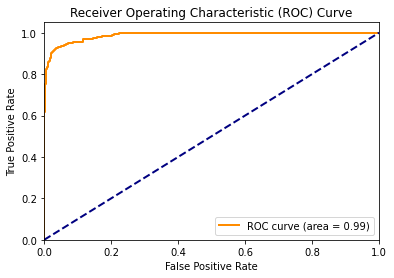

In [16]:

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Assuming y_test_seqs and y_pred_prob1 are already defined

# Calculate the ROC curve
fpr, tpr, _ = roc_curve(y_test_seqs, y_pred_prob1)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [ ]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_subgraph(graph, node1, node2):
    # Compute positions for all nodes in the graph
    pos = nx.spring_layout(graph)
    
    # Extract subgraph containing the two nodes and the shortest path between them
    subgraph_nodes = nx.shortest_path(graph, node1, node2)
    subgraph = graph.subgraph(subgraph_nodes)
    
    # Draw the full graph in light grey
    plt.figure(figsize=(8, 6))
    nx.draw(graph, pos, node_color='lightgrey', edge_color='lightgrey', with_labels=True, node_size=500)
    
    # Draw the subgraph with the selected nodes and edges
    nx.draw(subgraph, pos, with_labels=True, node_color='skyblue', edge_color='black', node_size=700)
    
    # Highlight the selected nodes
    nx.draw_networkx_nodes(graph, pos, nodelist=[node1, node2], node_color='orange', node_size=700)
    
    # Show node features
    node1_features = graph.nodes[node1]['combined_features']
    node2_features = graph.nodes[node2]['combined_features']
    print(f"Node {node1} features: {node1_features}")
    print(f"Node {node2} features: {node2_features}")
    
    # Show edge features if any (assuming there is an edge between the two nodes)
    if graph.has_edge(node1, node2):
        edge_features = graph[node1][node2]
        print(f"Edge features between node {node1} and node {node2}: {edge_features}")
    else:
        print(f"No edge directly connecting node {node1} and node {node2}")
    
    plt.show()

# Example usage:
# Assuming G is your graph and nodes 0 and 1 exist in your graph
plot_subgraph(train_graphs[0], 0, 1)


NameError: name 'train_graphs' is not defined